# Analyzing Dietary Habits Using Unsupervised Learning Techniques
**ARTI 308 – Machine Learning | Group 4**

| # | Name | ID | Role |
|---|------|----|------|
| 1 | Wesam Jaber Almalki | 2240005660 | Leader |
| 2 | Fahad Nawar Alotaibi | 2240002024 | Member |
| 3 | Fawaz Alshahrani | 2240005571 | Member |
| 4 | Faris Alshahrani | 2240005572 | Member |
| 5 | Ahmed Albouainain | 2240006128 | Member |
| 6 | Anas Hamzi | 2240003869 | Member |

---
**Objective:** Apply unsupervised learning (K-Means, Hierarchical Clustering) with dimensionality reduction (PCA, t-SNE) to discover hidden dietary behavior patterns without relying on predefined labels.

## Imports

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage

---
## 1. Load Data

In [19]:
df = pd.read_csv("dataset/diet_dataset_modified.csv")

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumns:\n{list(df.columns)}")
print(f"\nMissing values per column:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"\nData types:\n{df.dtypes.value_counts()}")

DATASET OVERVIEW
Shape: 1000 rows × 19 columns

Columns:
['Patient_ID', 'Age', 'Gender', 'Weight_kg', 'Height_cm', 'BMI', 'Disease_Type', 'Severity', 'Physical_Activity_Level', 'Daily_Caloric_Intake', 'Cholesterol_mg/dL', 'Blood_Pressure_mmHg', 'Glucose_mg/dL', 'Dietary_Restrictions', 'Allergies', 'Preferred_Cuisine', 'Weekly_Exercise_Hours', 'Adherence_to_Diet_Plan', 'Dietary_Nutrient_Imbalance_Score']

Missing values per column:
Dietary_Restrictions    334
Allergies               323
dtype: int64

Data types:
str        7
float64    7
int64      5
Name: count, dtype: int64


---
## 2. Exploratory Data Analysis
Inspect distributions of categorical and numerical features before modelling.


EXPLORATORY DATA ANALYSIS

Numerical summary:
           Age  Weight_kg  Height_cm      BMI  Physical_Activity_Level  \
count  1000.00    1000.00    1000.00  1000.00                  1000.00   
mean     49.86      84.60     174.82    28.19                     2.00   
std      18.11      20.09      14.33     8.04                     0.82   
min      18.00      50.00     150.00    13.00                     1.00   
25%      35.00      66.60     162.00    22.08                     1.00   
50%      50.00      85.20     175.00    27.45                     2.00   
75%      66.00     102.00     187.00    33.42                     3.00   
max      79.00     119.70     199.00    52.40                     3.00   

       Daily_Caloric_Intake  Cholesterol_mg/dL  Blood_Pressure_mmHg  \
count               1000.00            1000.00              1000.00   
mean                2475.06             199.72               144.99   
std                  565.02              29.08                20.25   
mi

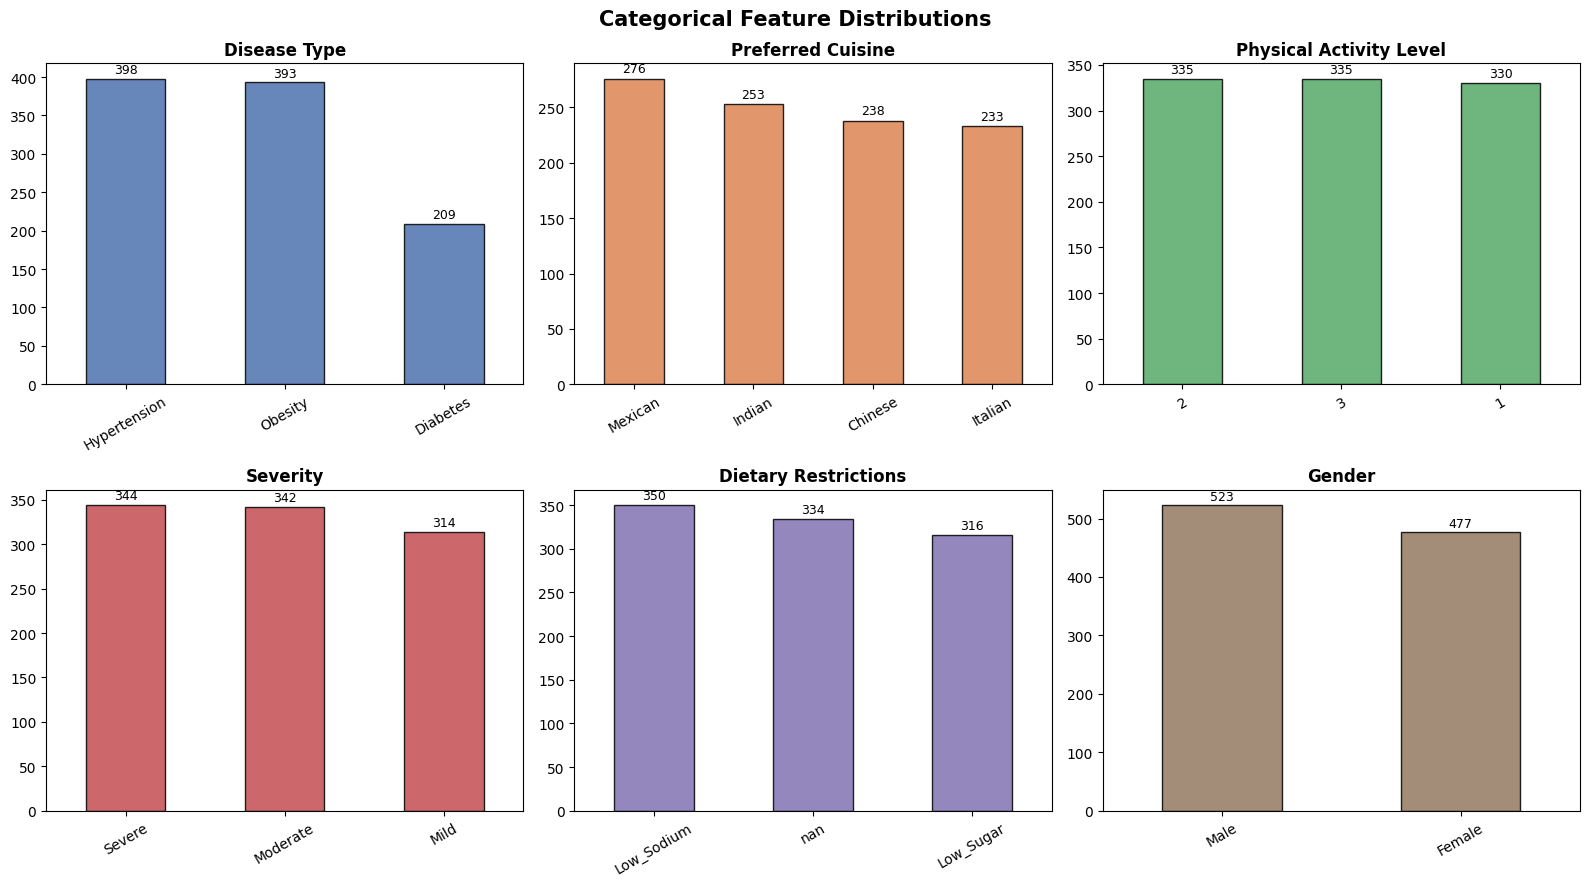

In [20]:
print("\n" + "=" * 60)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 60)

print("\nNumerical summary:")
print(df.describe().round(2))

print("\nCategorical distributions:")
for col in ["Gender", "Disease_Type", "Physical_Activity_Level",
            "Severity", "Dietary_Restrictions", "Preferred_Cuisine"]:
    print(f"\n{col}:\n{df[col].value_counts(dropna=False)}")

# Plot categorical distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Categorical Feature Distributions", fontsize=15, fontweight="bold")
cats = ["Disease_Type", "Preferred_Cuisine", "Physical_Activity_Level",
        "Severity", "Dietary_Restrictions", "Gender"]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]
for ax, col, color in zip(axes.flatten(), cats, colors):
    counts = df[col].value_counts(dropna=False)
    counts.index = counts.index.astype(str)
    counts.plot(kind="bar", ax=ax, color=color, edgecolor="black", alpha=0.85)
    ax.set_title(col.replace("_", " "), fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 3, int(bar.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("eda_categorical.png", dpi=150)
plt.show()

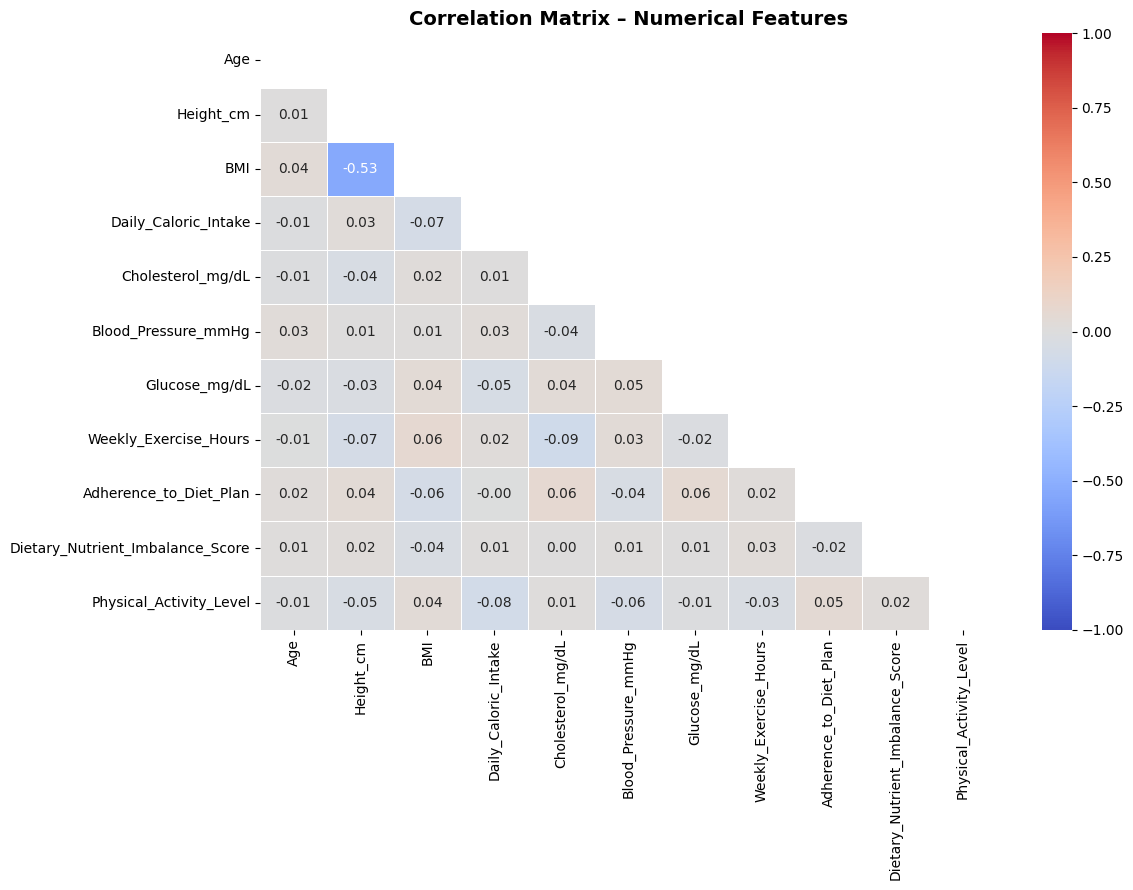

In [21]:
# Correlation heatmap (numerical features used in clustering)
num_cols = ["Age", "Height_cm", "BMI", "Daily_Caloric_Intake",
            "Cholesterol_mg/dL", "Blood_Pressure_mmHg", "Glucose_mg/dL",
            "Weekly_Exercise_Hours", "Adherence_to_Diet_Plan",
            "Dietary_Nutrient_Imbalance_Score", "Physical_Activity_Level"]

plt.figure(figsize=(12, 9))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix – Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_correlation.png", dpi=150)
plt.show()

---
## 3. Preprocessing & Feature Engineering
- `Disease_Type` and `Diet_Recommendation` are **excluded** from clustering input (saved for post-hoc validation only)
- Categorical features are label-encoded
- All features are standardized with `StandardScaler`

In [22]:
print("\n" + "=" * 60)
print("PREPROCESSING")
print("=" * 60)

# Patient_ID and Diet_Recommendation dropped entirely — no analytical value / target leak
# Disease_Type saved for post-hoc validation only, NOT a clustering input
labels_disease = df["Disease_Type"].copy()

# Weight_kg dropped: BMI already encodes weight relative to height (redundant)
numerical = [
    "Age", "Height_cm", "BMI", "Daily_Caloric_Intake",
    "Cholesterol_mg/dL", "Blood_Pressure_mmHg", "Glucose_mg/dL",
    "Weekly_Exercise_Hours", "Adherence_to_Diet_Plan",
    "Dietary_Nutrient_Imbalance_Score",
    "Physical_Activity_Level"   # ordinal: 1=Sedentary, 2=Moderate, 3=Active
]

categorical = [
    "Gender", "Severity",
    "Dietary_Restrictions", "Allergies", "Preferred_Cuisine"
]

# Fill NaN in categorical columns before encoding
df_encoded = df[numerical + categorical].copy()
df_encoded["Dietary_Restrictions"] = df_encoded["Dietary_Restrictions"].fillna("None")
df_encoded["Allergies"] = df_encoded["Allergies"].fillna("None")

# Encode categorical features
le = LabelEncoder()
for col in categorical:
    df_encoded[col] = le.fit_transform(df_encoded[col])

print(f"Feature matrix shape: {df_encoded.shape}")
print(f"Numerical features ({len(numerical)}): {numerical}")
print(f"Categorical features ({len(categorical)}): {categorical}")

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)
print("Standardization complete.")


PREPROCESSING
Feature matrix shape: (1000, 16)
Numerical features (11): ['Age', 'Height_cm', 'BMI', 'Daily_Caloric_Intake', 'Cholesterol_mg/dL', 'Blood_Pressure_mmHg', 'Glucose_mg/dL', 'Weekly_Exercise_Hours', 'Adherence_to_Diet_Plan', 'Dietary_Nutrient_Imbalance_Score', 'Physical_Activity_Level']
Categorical features (5): ['Gender', 'Severity', 'Dietary_Restrictions', 'Allergies', 'Preferred_Cuisine']
Standardization complete.


---
## 4. Dimensionality Reduction
PCA is used to determine how many components explain 95% of variance, then both PCA and t-SNE reduce to 2D for cluster visualization.


DIMENSIONALITY REDUCTION
Components needed for 95% variance: 15


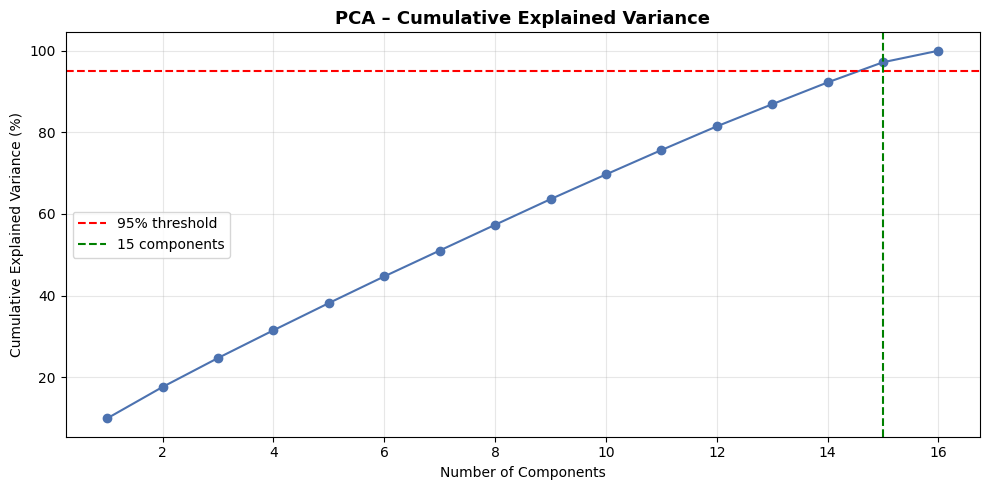

PCA 2D variance explained: 17.6%
Running t-SNE (this may take a moment)...
t-SNE complete.


In [23]:
print("\n" + "=" * 60)
print("DIMENSIONALITY REDUCTION")
print("=" * 60)

# PCA – explained variance
pca_full = PCA()
pca_full.fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cumvar >= 0.95) + 1
print(f"Components needed for 95% variance: {n_components_95}")

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumvar) + 1), cumvar * 100, marker="o", color="#4C72B0")
plt.axhline(95, color="red", linestyle="--", label="95% threshold")
plt.axvline(n_components_95, color="green", linestyle="--",
            label=f"{n_components_95} components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("PCA \u2013 Cumulative Explained Variance", fontsize=13, fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("pca_variance.png", dpi=150)
plt.show()

# Reduce to 2D for visualization
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)
print(f"PCA 2D variance explained: {pca_2d.explained_variance_ratio_.sum():.1%}")

# t-SNE 2D
print("Running t-SNE (this may take a moment)...")
tsne = TSNE(n_components=2, perplexity=40, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)
print("t-SNE complete.")

---
## 5. K-Means Clustering – Finding Optimal K
Three metrics are used to identify the best number of clusters:
- **Elbow Method** (Inertia / WSS)
- **Silhouette Score** (higher = better)
- **Davies-Bouldin Index** (lower = better)


K-MEANS – FINDING OPTIMAL K
  K=2  Inertia=14888  Silhouette=0.0657  DBI=3.6387
  K=3  Inertia=14341  Silhouette=0.0520  DBI=3.5373
  K=4  Inertia=13870  Silhouette=0.0523  DBI=3.4828
  K=5  Inertia=13524  Silhouette=0.0498  DBI=3.2992
  K=6  Inertia=13239  Silhouette=0.0490  DBI=3.1661
  K=7  Inertia=12983  Silhouette=0.0504  DBI=3.0279
  K=8  Inertia=12767  Silhouette=0.0505  DBI=2.9138
  K=9  Inertia=12599  Silhouette=0.0502  DBI=2.8519
  K=10  Inertia=12394  Silhouette=0.0509  DBI=2.7975


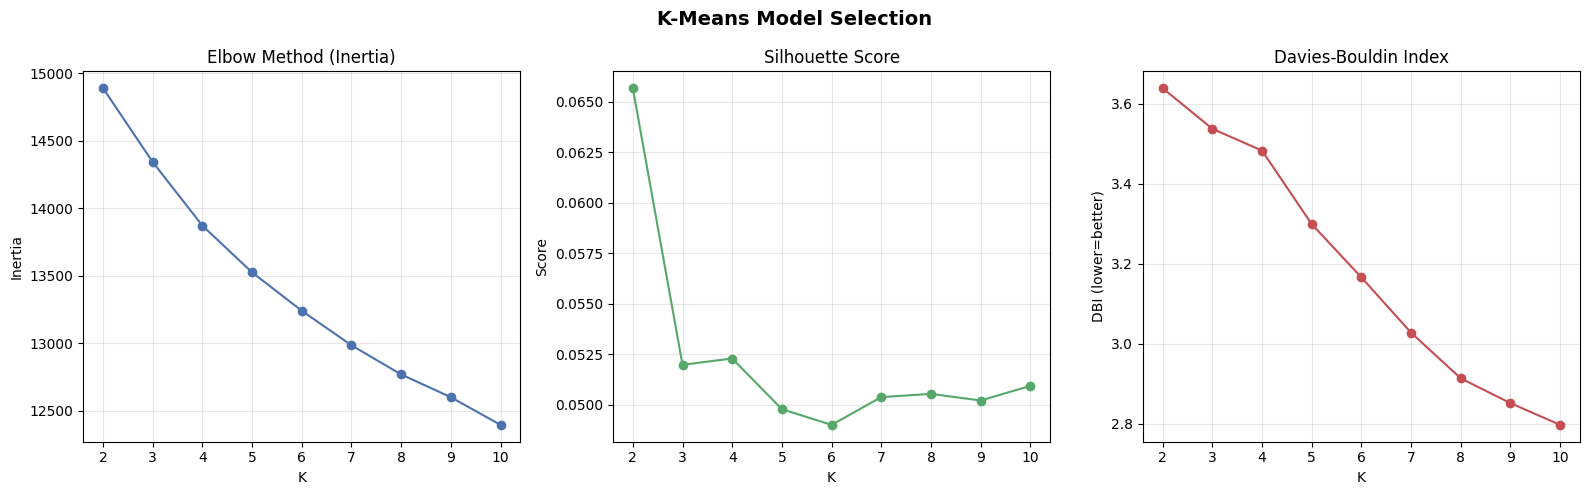


Best K by Silhouette Score: 2


In [24]:
print("\n" + "=" * 60)
print("K-MEANS \u2013 FINDING OPTIMAL K")
print("=" * 60)

inertias, silhouettes, dbi_scores = [], [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    dbi_scores.append(davies_bouldin_score(X_scaled, labels))
    print(f"  K={k}  Inertia={km.inertia_:.0f}  "
          f"Silhouette={silhouettes[-1]:.4f}  DBI={dbi_scores[-1]:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("K-Means Model Selection", fontsize=14, fontweight="bold")

axes[0].plot(K_range, inertias, marker="o", color="#4C72B0")
axes[0].set_title("Elbow Method (Inertia)")
axes[0].set_xlabel("K"); axes[0].set_ylabel("Inertia"); axes[0].grid(alpha=0.3)

axes[1].plot(K_range, silhouettes, marker="o", color="#55A868")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("K"); axes[1].set_ylabel("Score"); axes[1].grid(alpha=0.3)

axes[2].plot(K_range, dbi_scores, marker="o", color="#C44E52")
axes[2].set_title("Davies-Bouldin Index")
axes[2].set_xlabel("K"); axes[2].set_ylabel("DBI (lower=better)"); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("kmeans_selection.png", dpi=150)
plt.show()

best_k = K_range[np.argmax(silhouettes)]
print(f"\nBest K by Silhouette Score: {best_k}")

---
## 6. Final K-Means Model
Train the final K-Means model using the optimal K and visualize clusters via PCA and t-SNE projections.


FINAL K-MEANS MODEL  (K=2)
Silhouette Score : 0.0657
Davies-Bouldin   : 3.6387
Inertia          : 14888.25

Cluster sizes: {np.int32(0): np.int64(487), np.int32(1): np.int64(513)}


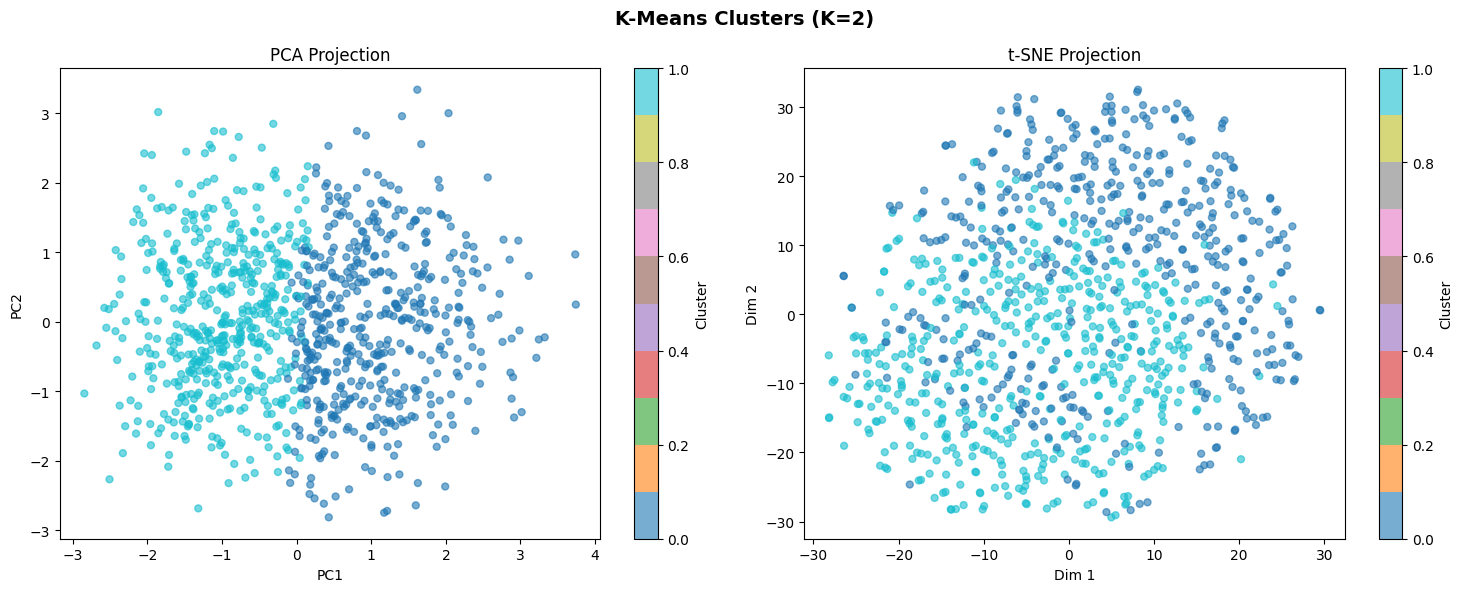

In [25]:
print("\n" + "=" * 60)
print(f"FINAL K-MEANS MODEL  (K={best_k})")
print("=" * 60)

km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
km_labels = km_final.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, km_labels)
dbi = davies_bouldin_score(X_scaled, km_labels)
print(f"Silhouette Score : {sil:.4f}")
print(f"Davies-Bouldin   : {dbi:.4f}")
print(f"Inertia          : {km_final.inertia_:.2f}")

# Cluster sizes
print(f"\nCluster sizes: {dict(zip(*np.unique(km_labels, return_counts=True)))}")

# Visualize clusters – PCA
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f"K-Means Clusters (K={best_k})", fontsize=14, fontweight="bold")

scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                           c=km_labels, cmap="tab10", alpha=0.6, s=25)
axes[0].set_title("PCA Projection"); axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
plt.colorbar(scatter1, ax=axes[0], label="Cluster")

scatter2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1],
                           c=km_labels, cmap="tab10", alpha=0.6, s=25)
axes[1].set_title("t-SNE Projection"); axes[1].set_xlabel("Dim 1"); axes[1].set_ylabel("Dim 2")
plt.colorbar(scatter2, ax=axes[1], label="Cluster")

plt.tight_layout()
plt.savefig("kmeans_clusters.png", dpi=150)
plt.show()

---
## 7. Hierarchical Clustering
Ward linkage dendrogram on a 200-sample subset, then Agglomerative Clustering fitted on the full dataset using the same K.


HIERARCHICAL CLUSTERING


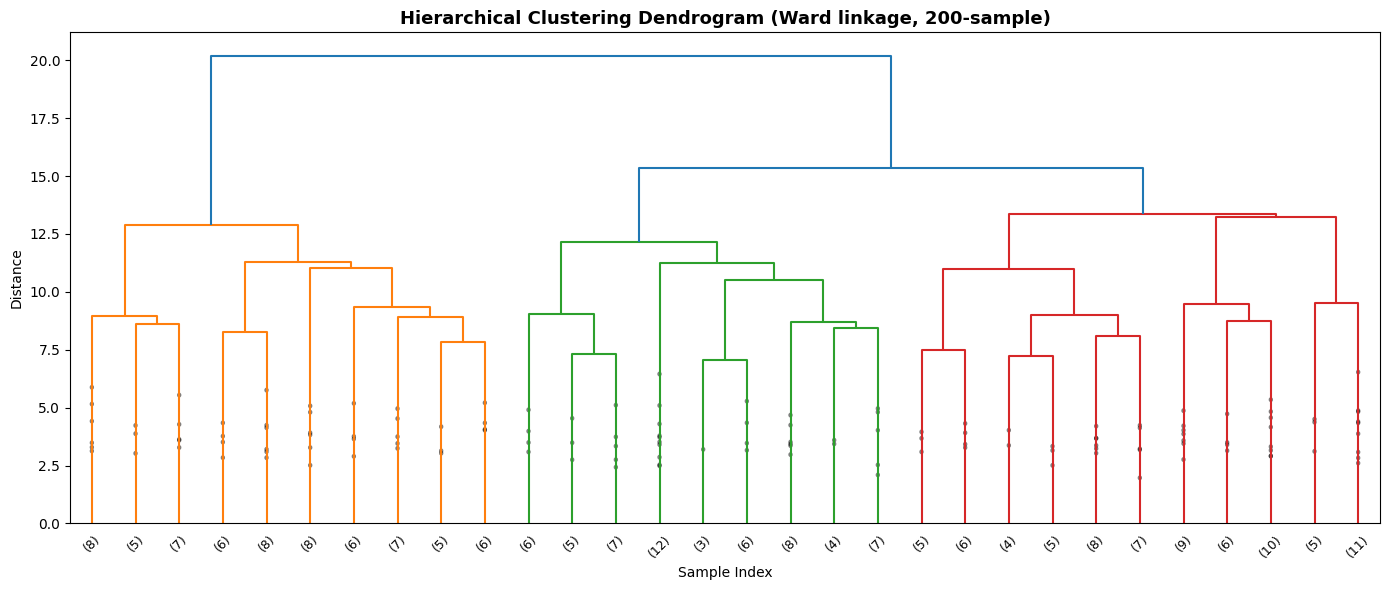

Silhouette Score : 0.0455
Davies-Bouldin   : 4.5067
Cluster sizes: {np.int64(0): np.int64(695), np.int64(1): np.int64(305)}


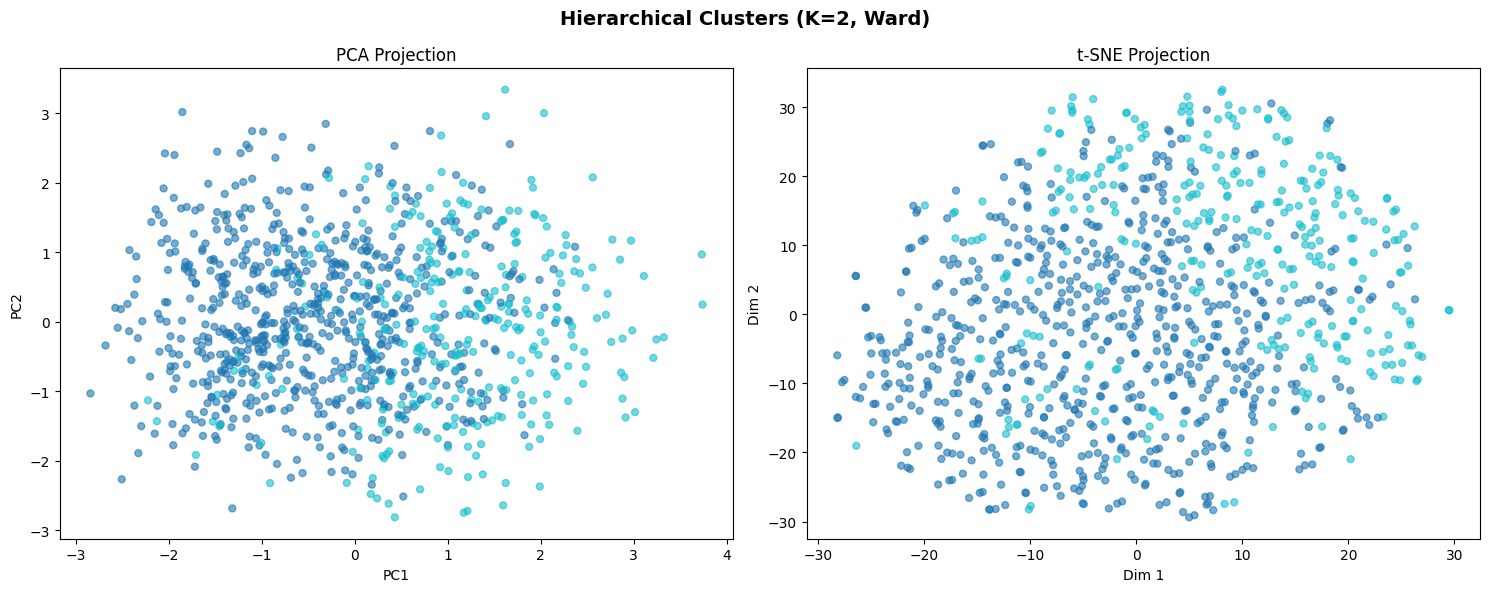

In [26]:
print("\n" + "=" * 60)
print("HIERARCHICAL CLUSTERING")
print("=" * 60)

# Dendrogram (sample 200 for readability)
sample_idx = np.random.choice(len(X_scaled), 200, replace=False)
Z = linkage(X_scaled[sample_idx], method="ward")

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=45,
           leaf_font_size=9, show_contracted=True,
           color_threshold=0.7 * max(Z[:, 2]))
plt.title("Hierarchical Clustering Dendrogram (Ward linkage, 200-sample)",
          fontsize=13, fontweight="bold")
plt.xlabel("Sample Index"); plt.ylabel("Distance")
plt.tight_layout()
plt.savefig("hierarchical_dendrogram.png", dpi=150)
plt.show()

# Fit Agglomerative with same K as best K-Means
agg = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
agg_labels = agg.fit_predict(X_scaled)

sil_agg = silhouette_score(X_scaled, agg_labels)
dbi_agg = davies_bouldin_score(X_scaled, agg_labels)
print(f"Silhouette Score : {sil_agg:.4f}")
print(f"Davies-Bouldin   : {dbi_agg:.4f}")
print(f"Cluster sizes: {dict(zip(*np.unique(agg_labels, return_counts=True)))}")

# Visualize – PCA
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f"Hierarchical Clusters (K={best_k}, Ward)", fontsize=14, fontweight="bold")

axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                c=agg_labels, cmap="tab10", alpha=0.6, s=25)
axes[0].set_title("PCA Projection"); axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")

axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1],
                c=agg_labels, cmap="tab10", alpha=0.6, s=25)
axes[1].set_title("t-SNE Projection"); axes[1].set_xlabel("Dim 1"); axes[1].set_ylabel("Dim 2")

plt.tight_layout()
plt.savefig("hierarchical_clusters.png", dpi=150)
plt.show()

---
## 8. Algorithm Comparison
Side-by-side bar charts comparing K-Means vs. Hierarchical (Ward) on Silhouette Score and Davies-Bouldin Index.


ALGORITHM COMPARISON
          Algorithm  Clusters (K)  Silhouette  Davies-Bouldin
            K-Means             2      0.0657          3.6387
Hierarchical (Ward)             2      0.0455          4.5067


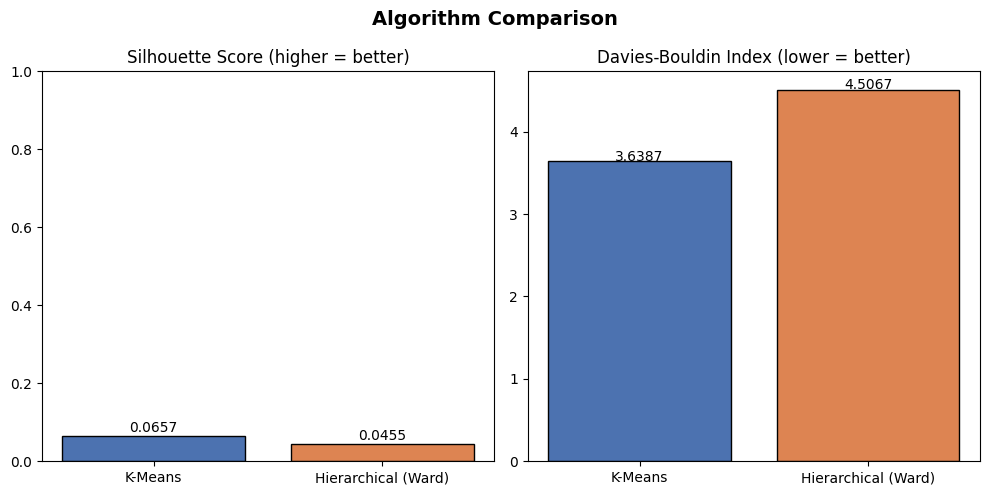

In [27]:
print("\n" + "=" * 60)
print("ALGORITHM COMPARISON")
print("=" * 60)

comparison = pd.DataFrame({
    "Algorithm":       ["K-Means", "Hierarchical (Ward)"],
    "Clusters (K)":   [best_k, best_k],
    "Silhouette":      [round(sil, 4), round(sil_agg, 4)],
    "Davies-Bouldin":  [round(dbi, 4), round(dbi_agg, 4)],
})
print(comparison.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Algorithm Comparison", fontsize=14, fontweight="bold")

axes[0].bar(comparison["Algorithm"], comparison["Silhouette"],
            color=["#4C72B0", "#DD8452"], edgecolor="black")
axes[0].set_title("Silhouette Score (higher = better)")
axes[0].set_ylim(0, 1)
for bar, val in zip(axes[0].patches, comparison["Silhouette"]):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.01, f"{val:.4f}", ha="center")

axes[1].bar(comparison["Algorithm"], comparison["Davies-Bouldin"],
            color=["#4C72B0", "#DD8452"], edgecolor="black")
axes[1].set_title("Davies-Bouldin Index (lower = better)")
for bar, val in zip(axes[1].patches, comparison["Davies-Bouldin"]):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.01, f"{val:.4f}", ha="center")

plt.tight_layout()
plt.savefig("algorithm_comparison.png", dpi=150)
plt.show()

---
## 9. Cluster Profiling (K-Means)
- Mean feature values per cluster reveal each group's dietary and health profile
- Cross-tabulation against `Disease_Type` and `Diet_Recommendation` serves as post-hoc validation
- Radar chart provides a visual summary of normalized cluster profiles

In [28]:
print("\n" + "=" * 60)
print("CLUSTER PROFILING (K-MEANS)")
print("=" * 60)

df_result = df_encoded.copy()
df_result["KMeans_Cluster"] = km_labels
df_result["Disease_Type"]   = labels_disease.values

# Mean of numerical features per cluster
profile = df_result.groupby("KMeans_Cluster")[numerical].mean().round(2)
print("\nCluster means (numerical features):")
print(profile.T)

# Post-hoc validation: do clusters align with Disease_Type?
print("\nCluster vs Disease_Type (post-hoc validation):")
print(pd.crosstab(km_labels, labels_disease))


CLUSTER PROFILING (K-MEANS)

Cluster means (numerical features):
KMeans_Cluster                          0        1
Age                                 50.32    49.42
Height_cm                          163.29   185.76
BMI                                 33.60    23.06
Daily_Caloric_Intake              2410.26  2536.59
Cholesterol_mg/dL                  201.20   198.31
Blood_Pressure_mmHg                146.68   143.39
Glucose_mg/dL                      138.06   135.74
Weekly_Exercise_Hours                5.56     4.79
Adherence_to_Diet_Plan              73.08    76.60
Dietary_Nutrient_Imbalance_Score     2.41     2.52
Physical_Activity_Level              2.03     1.98

Cluster vs Disease_Type (post-hoc validation):
Disease_Type  Diabetes  Hypertension  Obesity
row_0                                        
0                   84            69      334
1                  125           329       59


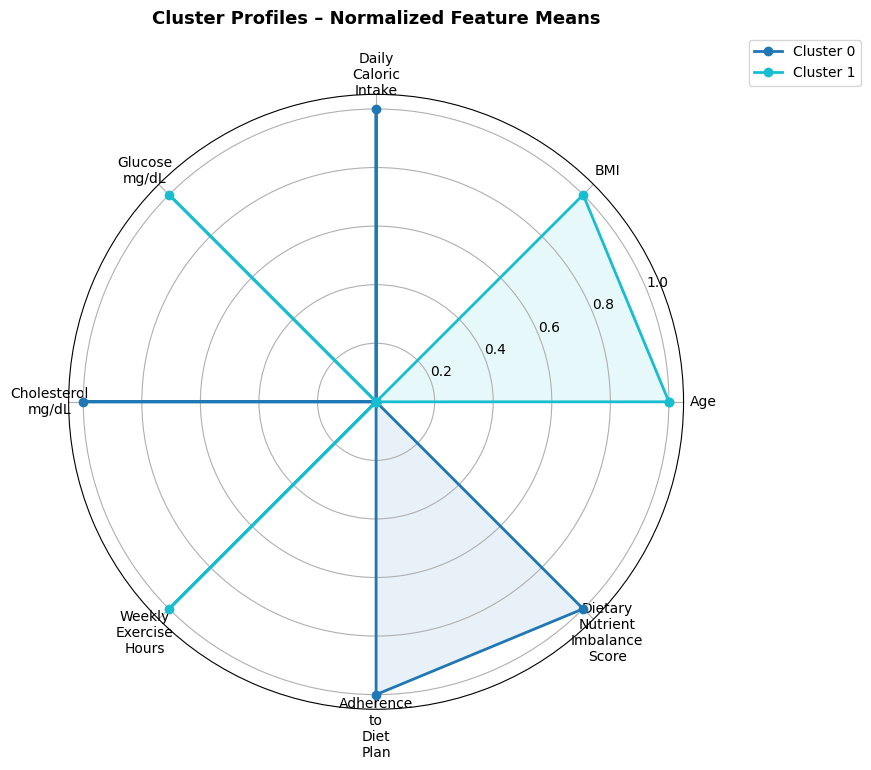

In [16]:
# Radar chart – cluster profiles (normalized 0-1)
from sklearn.preprocessing import MinMaxScaler
radar_features = ["Age", "BMI", "Daily_Caloric_Intake",
                  "Glucose_mg/dL", "Cholesterol_mg/dL",
                  "Weekly_Exercise_Hours", "Adherence_to_Diet_Plan",
                  "Dietary_Nutrient_Imbalance_Score"]

profile_radar = df_result.groupby("KMeans_Cluster")[radar_features].mean()
profile_norm  = pd.DataFrame(
    MinMaxScaler().fit_transform(profile_radar),
    columns=radar_features,
    index=profile_radar.index
)

angles = np.linspace(0, 2 * np.pi, len(radar_features), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
colors_radar = plt.cm.tab10(np.linspace(0, 1, best_k))
for i, row in profile_norm.iterrows():
    vals = row.tolist() + row.tolist()[:1]
    ax.plot(angles, vals, "o-", linewidth=2, label=f"Cluster {i}", color=colors_radar[i])
    ax.fill(angles, vals, alpha=0.1, color=colors_radar[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels([f.replace("_", "\n") for f in radar_features], size=10)
ax.set_title("Cluster Profiles \u2013 Normalized Feature Means",
             size=13, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig("cluster_profiles_radar.png", dpi=150)
plt.show()

---
## 10. Final Summary Report

In [ ]:
print("\n" + "=" * 60)
print("FINAL SUMMARY REPORT")
print("=" * 60)
print(f"""
Dataset          : diet_dataset_modified.csv
Records          : {df.shape[0]}
Features used    : {len(numerical) + len(categorical)} ({len(numerical)} numerical + {len(categorical)} categorical)
Dropped entirely : Patient_ID, Diet_Recommendation, Weight_kg (redundant with BMI)
Post-hoc only    : Disease_Type (validation after clustering)

Dimensionality Reduction
  PCA 2D variance : {pca_2d.explained_variance_ratio_.sum():.1%}
  Components for 95% variance: {n_components_95}

Clustering Results
  Optimal K       : {best_k}  (by Silhouette Score)

  K-Means
    Silhouette    : {sil:.4f}
    Davies-Bouldin: {dbi:.4f}
    Inertia       : {km_final.inertia_:.2f}

  Hierarchical (Ward)
    Silhouette    : {sil_agg:.4f}
    Davies-Bouldin: {dbi_agg:.4f}

Saved figures:
  eda_categorical.png
  eda_correlation.png
  pca_variance.png
  kmeans_selection.png
  kmeans_clusters.png
  hierarchical_dendrogram.png
  hierarchical_clusters.png
  algorithm_comparison.png
  cluster_profiles_radar.png
""")